In [1]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# If you have the raw data run those





In [1]:
import pandas as pd
import os

# Column names
columns = ['unit id', 'cycle', 'op_set_1', 'op_set_2', 'op_set_3'] + \
          [f's{i}' for i in range(1, 22)]

# Input folder (where your txt files are)
input_folder = "data/raw"

# Output folder
output_folder = "data/csv"
os.makedirs(output_folder, exist_ok=True)

# Mapping filenames
file_mapping = {
    "/content/train_FD001.txt": "train_1.csv",
    "/content/train_FD002.txt": "train_2.csv",
    "/content/train_FD003.txt": "train_3.csv",
    "/content/train_FD004.txt": "train_4.csv",
    "/content/test_FD001.txt": "test_1.csv",
    "/content/test_FD002.txt": "test_2.csv",
    "/content/test_FD003.txt": "test_3.csv",
    "/content/test_FD004.txt": "test_4.csv",
    "/content/RUL_FD001.txt": "RUL_1.csv",
    "/content/RUL_FD002.txt": "RUL_2.csv",
    "/content/RUL_FD003.txt": "RUL_3.csv",
    "/content/RUL_FD004.txt": "RUL_4.csv",
}

for file_name, new_name in file_mapping.items():
    file_path = os.path.join(input_folder, file_name)

    # Read txt file (CMAPSS uses space-separated values with possible extra spaces)
    df = pd.read_csv(file_path, sep=r"\s+", header=None)

    # Drop any extra empty columns (CMAPSS files sometimes have trailing spaces)
    df = df.dropna(axis=1, how='all')

    # Assign column names
    if df.shape[1] == len(columns):
        df.columns = columns
    else:
        print(f"Warning: {file_name} has {df.shape[1]} columns, expected {len(columns)}")

    # Save as CSV
    output_path = os.path.join(output_folder, new_name)
    df.to_csv(output_path, index=False)

    print(f"Saved: {output_path}")

Saved: data/csv/train_1.csv
Saved: data/csv/train_2.csv
Saved: data/csv/train_3.csv
Saved: data/csv/train_4.csv
Saved: data/csv/test_1.csv
Saved: data/csv/test_2.csv
Saved: data/csv/test_3.csv
Saved: data/csv/test_4.csv
Saved: data/csv/RUL_1.csv
Saved: data/csv/RUL_2.csv
Saved: data/csv/RUL_3.csv
Saved: data/csv/RUL_4.csv


In [24]:
train_1 = pd.read_csv("data/csv/train_1.csv")
train_2 = pd.read_csv("data/csv/train_2.csv")
train_3 = pd.read_csv("data/csv/train_3.csv")
train_4 = pd.read_csv("data/csv/train_4.csv")

test_1 = pd.read_csv("data/csv/test_1.csv")
test_2 = pd.read_csv("data/csv/test_2.csv")
test_3 = pd.read_csv("data/csv/test_3.csv")
test_4 = pd.read_csv("data/csv/test_4.csv")

rul_1 = pd.read_csv("data/csv/RUL_1.csv")
rul_2 = pd.read_csv("data/csv/RUL_2.csv")
rul_3 = pd.read_csv("data/csv/RUL_3.csv")
rul_4 = pd.read_csv("data/csv/RUL_4.csv")

# if you have the excel sheets run this if not dont run those cells

In [2]:
all_train_sheets = pd.read_excel('/content/All_train_data.xlsx', sheet_name=None)

print("Sheets found in the Excel file:")
for sheet_name in all_train_sheets.keys():
    print(f"{sheet_name}")

Sheets found in the Excel file:
train_FD001(HPC Degradation)
train_FD002(HPC Degradation)
train_FD003(HPC+Fan_Deg)
train_FD004(HPC+Fan_Deg)


In [3]:
all_test_sheets = pd.read_excel('/content/All_test_data.xlsx', sheet_name=None)

print("Sheets found in the Excel file:")
for sheet_name in all_test_sheets.keys():
    print(f"{sheet_name}")

Sheets found in the Excel file:
test_FD001(HPC_degradation)
test_FD002(HPC_degradation)
test_FD003(HPC+Fan degradation)
test_FD004(HPC+Fan degradation)


In [4]:
RUL_data = pd.read_excel('/content/RUL_data.xlsx', sheet_name=None)
print("Sheets found in the Excel file:")
for sheet_name in RUL_data.keys():
    print(f"{sheet_name}")

Sheets found in the Excel file:
RUL_FD001
RUL_FD002
RUL_FD003
RUL_FD004


In [3]:
#upload the .xlsx sheets and choose the files suitble for the process
train_1 = all_train_sheets["train_FD001(HPC Degradation)"]
train_2 = all_train_sheets["train_FD002(HPC Degradation)"]
train_3 = all_train_sheets["train_FD003(HPC+Fan_Deg)"]
train_4 = all_train_sheets["train_FD004(HPC+Fan_Deg)"]

test_1 = all_test_sheets["test_FD001(HPC_degradation)"]
test_2 = all_test_sheets["test_FD002(HPC_degradation)"]
test_3 = all_test_sheets["test_FD003(HPC+Fan degradation)"]
test_4 = all_test_sheets["test_FD004(HPC+Fan degradation)"]

rul_1 = RUL_data["RUL_FD001"]
rul_2 = RUL_data["RUL_FD002"]
rul_3 = RUL_data["RUL_FD003"]
rul_4 = RUL_data["RUL_FD004"]

print(f'train_1 shape: {train_1.shape}')
print(f'train_2 shape: {train_2.shape}')
print(f'train_3 shape: {train_3.shape}')
print(f'train_4 shape: {train_4.shape}')

print(f'test_1 shape: {test_1.shape}')
print(f'test_2 shape: {test_2.shape}')
print(f'test_3 shape: {test_3.shape}')
print(f'test_4 shape: {test_4.shape}')

print(f'rul_1 shape: {rul_1.shape}')
print(f'rul_2 shape: {rul_2.shape}')
print(f'rul_3 shape: {rul_3.shape}')
print(f'rul_4 shape: {rul_4.shape}')


NameError: name 'all_train_sheets' is not defined

# Data cleaning

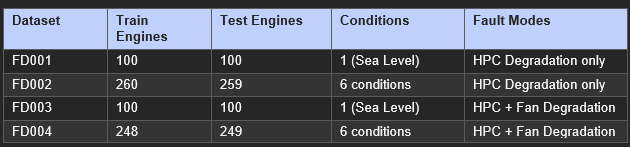

a way can let you have a better intuation about the data shape
for example

is this
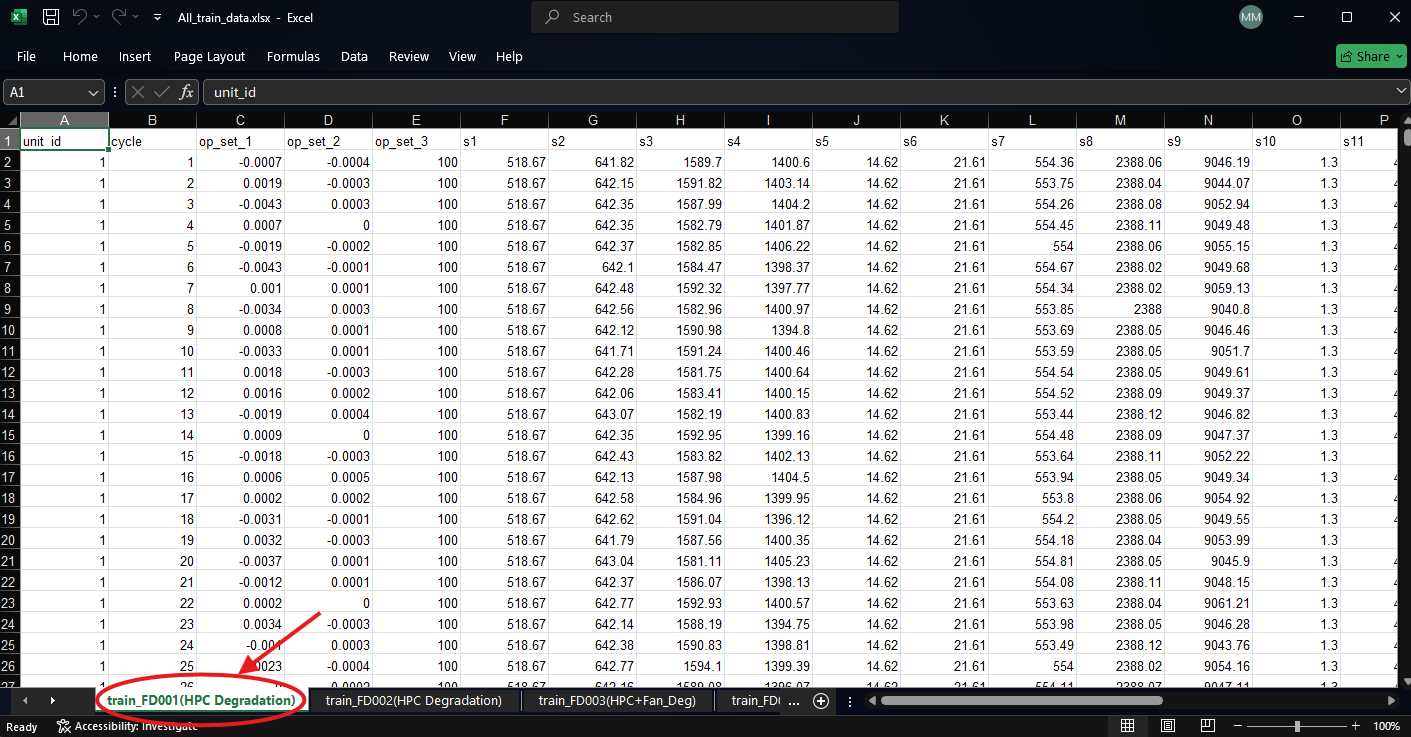

the same goes for the others variables

In [4]:
train_1.head()

,unit id,cycle,op_set_1,op_set_2,op_set_3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


Every row represents one operational cycle of one engine. Here is what each column means:
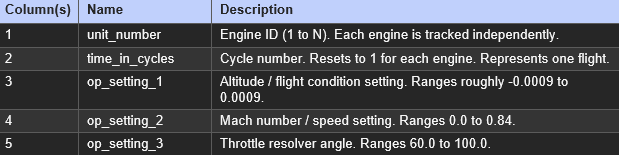

These sensors capture the engine's physical state at each cycle. Some sensors are very informative (they change with degradation), while others are nearly constant (low information value):

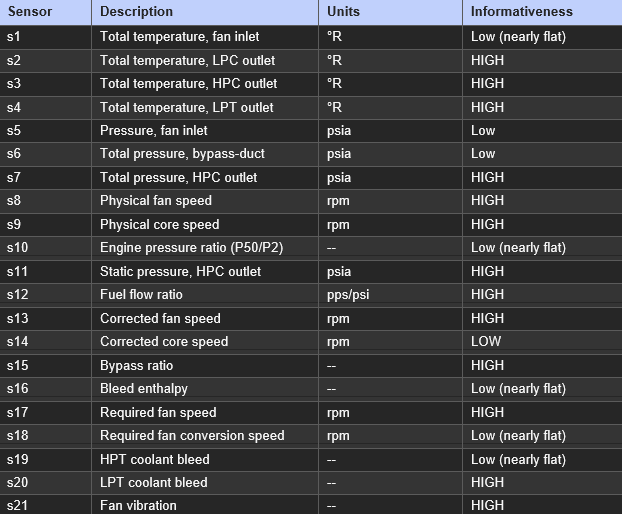

In [5]:
test_1.head()

,unit id,cycle,op_set_1,op_set_2,op_set_3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,521.72,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,522.16,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,521.97,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,521.38,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,522.15,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130


In [6]:
rul_1.head()

NameError: name 'rul_1' is not defined

In [7]:
#missing values for the train data
print("train_1 null no.:", train_1.T.isnull().sum().sum())
print("train_2 null no.:", train_2.T.isnull().sum().sum())
print("train_3 null no.:", train_3.T.isnull().sum().sum())
print("train_4 null no.:", train_4.T.isnull().sum().sum())

train_1 null no.: 0
train_2 null no.: 0
train_3 null no.: 0
train_4 null no.: 0


In [8]:
#missing values for the test data
print("test_1 null no.:", test_1.T.isnull().sum().sum())
print("test_2 null no.:", test_2.T.isnull().sum().sum())
print("test_3 null no.:", test_3.T.isnull().sum().sum())
print("test_4 null no.:", test_4.T.isnull().sum().sum())

test_1 null no.: 0
test_2 null no.: 0
test_3 null no.: 0
test_4 null no.: 0


In [20]:
#missing data fot the train data
print("RUL_1 null no.:", rul_1.T.isnull().sum().sum())
print("RUL_2 null no.:", rul_2.T.isnull().sum().sum())
print("RUL_3 null no.:", rul_3.T.isnull().sum().sum())
print("RUL_4 null no.:", rul_4.T.isnull().sum().sum())

RUL_1 null no.: 0
RUL_2 null no.: 0
RUL_3 null no.: 0
RUL_4 null no.: 0


In [21]:
#statstics overview for the train data
print("train_1 null no.:", train_1.describe().T)
print("train_2 null no.:", train_2.describe().T)
print("train_3 null no.:", train_3.describe().T)
print("train_4 null no.:", train_4.describe().T)

train_1 null no.:             count         mean           std        min        25%        50%  \
unit id   20631.0    51.506568  2.922763e+01     1.0000    26.0000    52.0000   
cycle     20631.0   108.807862  6.888099e+01     1.0000    52.0000   104.0000   
op_set_1  20631.0    -0.000009  2.187313e-03    -0.0087    -0.0015     0.0000   
op_set_2  20631.0     0.000002  2.930621e-04    -0.0006    -0.0002     0.0000   
op_set_3  20631.0   100.000000  0.000000e+00   100.0000   100.0000   100.0000   
s1        20631.0   518.670000  6.537152e-11   518.6700   518.6700   518.6700   
s2        20631.0   642.680934  5.000533e-01   641.2100   642.3250   642.6400   
s3        20631.0  1590.523119  6.131150e+00  1571.0400  1586.2600  1590.1000   
s4        20631.0  1408.933782  9.000605e+00  1382.2500  1402.3600  1408.0400   
s5        20631.0    14.620000  3.394700e-12    14.6200    14.6200    14.6200   
s6        20631.0    21.609803  1.388985e-03    21.6000    21.6100    21.6100   
s7        

In [22]:
print("test_1 null no.:", test_1.describe().T)
print("test_2 null no.:", test_2.describe().T)
print("test_3 null no.:", test_3.describe().T)
print("test_4 null no.:", test_4.describe().T)

test_1 null no.:             count         mean           std        min        25%        50%  \
unit id   13096.0    51.543907  2.828942e+01     1.0000    28.0000    52.0000   
cycle     13096.0    76.836515  5.305775e+01     1.0000    33.0000    69.0000   
op_set_1  13096.0    -0.000011  2.202685e-03    -0.0082    -0.0015    -0.0000   
op_set_2  13096.0     0.000004  2.940306e-04    -0.0006    -0.0002    -0.0000   
op_set_3  13096.0   100.000000  0.000000e+00   100.0000   100.0000   100.0000   
s1        13096.0   518.670000  6.014263e-11   518.6700   518.6700   518.6700   
s2        13096.0   642.475088  4.008993e-01   641.1300   642.1975   642.4600   
s3        13096.0  1588.099204  5.003274e+00  1569.0400  1584.6000  1587.9900   
s4        13096.0  1404.735362  6.688309e+00  1384.3900  1399.9500  1404.4400   
s5        13096.0    14.620000  2.671743e-12    14.6200    14.6200    14.6200   
s6        13096.0    21.609701  1.704085e-03    21.6000    21.6100    21.6100   
s7        1

In [12]:
# Some sensors show no changes in mean and standard deviation, indicating they do not detect sudden changes.
sensor_cols = [f's{i}' for i in range(1, 22)]

for sheet_name, df in all_train_sheets.items():

    print(f"{sheet_name}")
    print("==================================================")

    std_vals = df[sensor_cols].std()
    flat_sensors = std_vals[std_vals < 0.01].index.tolist()

    print(f"Flat sensors (std < 0.01): {flat_sensors}")
    print("\nAll sensors std values:")
    print(std_vals.sort_values())

NameError: name 'all_train_sheets' is not defined

In [ ]:
print("RUL_1 null no.:", rul_1.describe())
print("RUL_2 null no.:", rul_2.describe())
print("RUL_3 null no.:", rul_3.describe())
print("RUL_4 null no.:", rul_4.describe())

In [ ]:
#now we need to add the RUL to the traning data
#RUL at cycle t = (max cycle for that engnine) - t (the no. of cycle)
# For each training sheet, calculate RUL

for sheet_name, df in all_train_sheets.items():

    #get max cycle per engine
    max_cycles = df.groupby('unit_id')['cycle'].max().reset_index()
    max_cycles.columns = ['unit_id', 'max_cycle']

    df = df.merge(max_cycles, on='unit_id')

    #calculate RUL = (max cycle for that engnine) - t (the no. of cycle)
    df['RUL'] = df['max_cycle'] - df['cycle']


    df.drop(columns=['max_cycle'], inplace=True)

    # Step 5: update the sheet back
    all_train_sheets[sheet_name] = df

print("train_FD001",all_train_sheets['train_FD001(HPC Degradation)'][['unit_id', 'cycle', 'RUL']].head(10))
print("train_FD002",all_train_sheets['train_FD002(HPC Degradation)'][['unit_id', 'cycle', 'RUL']].head(10))
print("train_FD003",all_train_sheets['train_FD003(HPC+Fan_Deg)'][['unit_id', 'cycle', 'RUL']].head(10))
print("train_FD004",all_train_sheets['train_FD004(HPC+Fan_Deg)'][['unit_id', 'cycle', 'RUL']].head(10))

In [ ]:
for sheet_name, df in all_train_sheets.items():
    sensor_cols = [f's{i}' for i in range(1, 22)]
    std_vals = df[sensor_cols].std()  # raw unscaled std
    flat_sensors = std_vals[std_vals < 0.01].index.tolist()
    all_train_sheets[sheet_name] = df.drop(columns=flat_sensors)
    print(f"{sheet_name} dropped: {flat_sensors}")


In [ ]:
scalers = {}
for sheet_name, df in all_train_sheets.items():

    # Get sensor cols FROM EACH SHEET not from FD001
    sensor_cols = [c for c in df.columns if c.startswith('s')]

    scaler = MinMaxScaler()
    df[sensor_cols] = scaler.fit_transform(df[sensor_cols])
    all_train_sheets[sheet_name] = df
    scalers[sheet_name] = scaler
    print(f"{sheet_name}  scaled ")

In [ ]:
train_1 = all_train_sheets['train_FD001(HPC Degradation)']
train_2 = all_train_sheets['train_FD002(HPC Degradation)']
train_3 = all_train_sheets['train_FD003(HPC+Fan_Deg)']
train_4 = all_train_sheets['train_FD004(HPC+Fan_Deg)']

on the data files FD_001 and FD_003 the s1 is not there since is no variance in sensor reading but in the FD_002 and FD_004 the s1 is there so we normlized it

In [ ]:
train_1.head()

In [ ]:
train_2.head()

In [13]:
sensor_cols = [f's{i}' for i in range(1, 22)]

for sheet_name, df in all_test_sheets.items():

    print(f"{sheet_name}")
    print("==================================================")

    std_vals = df[sensor_cols].std()
    flat_sensors = std_vals[std_vals < 0.01].index.tolist()

    print(f"Flat sensors (std < 0.01): {flat_sensors}")
    print("\nAll sensors std values:")
    print(std_vals.sort_values())

NameError: name 'all_test_sheets' is not defined

In [14]:
scalers = {}
for sheet_name, df in all_test_sheets.items():

    # Get sensor cols FROM EACH SHEET not from FD001
    sensor_cols = [c for c in df.columns if c.startswith('s')]

    scaler = MinMaxScaler()
    df[sensor_cols] = scaler.fit_transform(df[sensor_cols])
    all_test_sheets[sheet_name] = df
    scalers[sheet_name] = scaler
    print(f"{sheet_name}  scaled ")

NameError: name 'all_test_sheets' is not defined

In [15]:
test_1.head()

,unit id,cycle,op_set_1,op_set_2,op_set_3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,521.72,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,522.16,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,521.97,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,521.38,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,522.15,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130


In [16]:
from sklearn.cluster import KMeans

op_settings_train2 = train_2[['op_set_1', 'op_set_2', 'op_set_3']]
op_settings_test2  = test_2[['op_set_1', 'op_set_2', 'op_set_3']]
op_settings_train4 = train_4[['op_set_1', 'op_set_2', 'op_set_3']]
op_settings_test4  = test_4[['op_set_1', 'op_set_2', 'op_set_3']]

# FD002
kmeans_2 = KMeans(n_clusters=6, random_state=42, n_init=10)
train_2['op_cluster'] = kmeans_2.fit_predict(op_settings_train2)  # fit + assign labels
test_2['op_cluster']  = kmeans_2.predict(op_settings_test2)        # same scaler, predict only

# FD004 — needs its OWN kmeans, not the same one!
kmeans_4 = KMeans(n_clusters=6, random_state=42, n_init=10)
train_4['op_cluster'] = kmeans_4.fit_predict(op_settings_train4)
test_4['op_cluster']  = kmeans_4.predict(op_settings_test4)

In [17]:
train_2.head()

,unit id,cycle,op_set_1,op_set_2,op_set_3,s1,s2,s3,s4,s5,...,s13,s14,s15,s16,s17,s18,s19,s20,s21,op_cluster
0,1,1,34.9983,0.8400,100.0,449.44,555.32,1358.61,1137.23,5.48,...,2387.72,8048.56,9.3461,0.02,334,2223,100.00,14.73,8.8071,5
1,1,2,41.9982,0.8408,100.0,445.00,549.90,1353.22,1125.78,3.91,...,2387.66,8072.30,9.3774,0.02,330,2212,100.00,10.41,6.2665,0
2,1,3,24.9988,0.6218,60.0,462.54,537.31,1256.76,1047.45,7.05,...,2028.03,7864.87,10.8941,0.02,309,1915,84.93,14.08,8.6723,2
3,1,4,42.0077,0.8416,100.0,445.00,549.51,1354.03,1126.38,3.91,...,2387.61,8068.66,9.3528,0.02,329,2212,100.00,10.59,6.4701,0
4,1,5,25.0005,0.6203,60.0,462.54,537.07,1257.71,1047.93,7.05,...,2028.00,7861.23,10.8963,0.02,309,1915,84.93,14.13,8.5286,2


# Plotting


Number of axes: 4


NameError: name 'all_train_sheets' is not defined

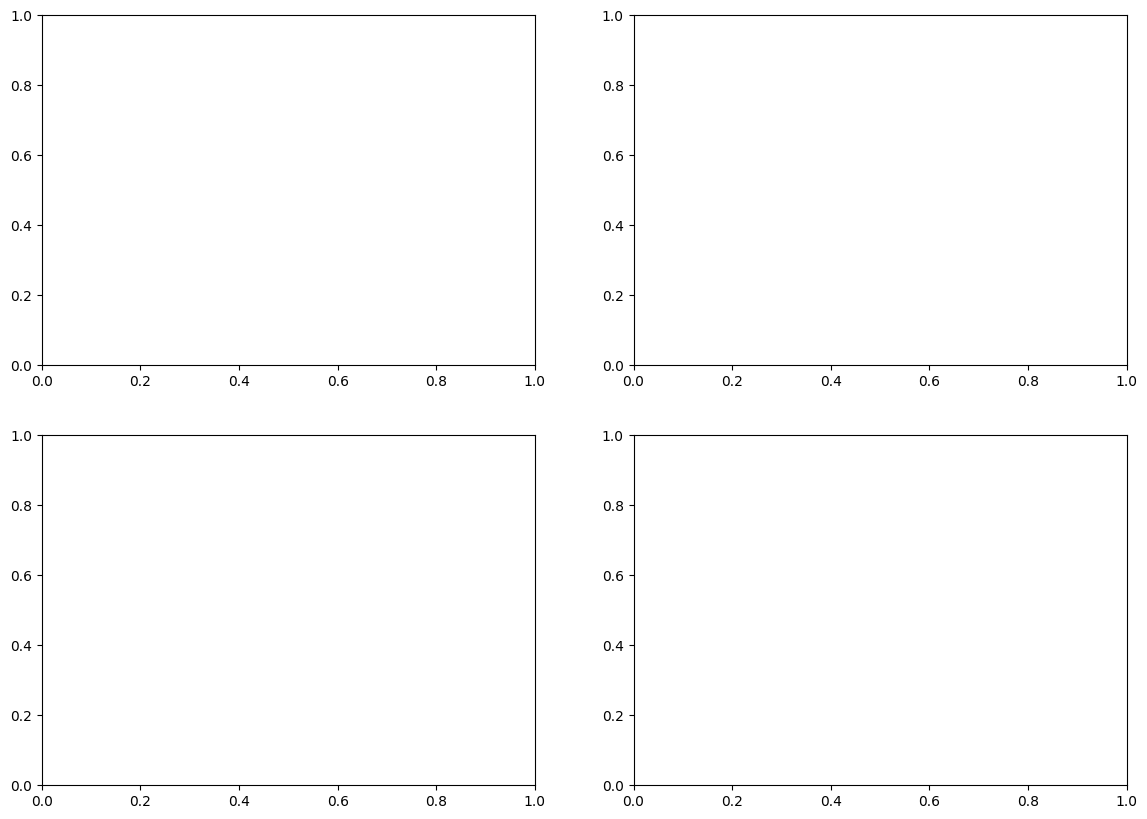

In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

print(f"Number of axes: {len(axes)}")
print(f"Number of sheets: {len(all_train_sheets)}")

for i, (sheet_name, df) in enumerate(all_train_sheets.items()):
    print(f"i={i}, sheet={sheet_name}")  # check what i values come out
    axes[i].hist(df['RUL'], bins=50, color='coral', edgecolor='white', alpha=0.85)
    axes[i].set_title(sheet_name, fontweight='bold')
    axes[i].set_xlabel('RUL (cycles)')
    axes[i].set_ylabel('Count')

plt.suptitle('RUL Distribution — All Datasets', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

datasets = {
    'FD001': train_1, 'FD002': train_2,
    'FD003': train_3, 'FD004': train_4
}

for i, (name, df) in enumerate(datasets.items()):
    lifetimes = df.groupby('unit_id')['cycle'].max()
    axes[i].hist(lifetimes, bins=20, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].axvline(lifetimes.mean(),   color='red',    linestyle='--', label=f'Mean:   {lifetimes.mean():.0f}')
    axes[i].axvline(lifetimes.median(), color='orange', linestyle='--', label=f'Median: {lifetimes.median():.0f}')
    axes[i].axvline(lifetimes.min(),    color='green',  linestyle=':',  label=f'Min:    {lifetimes.min():.0f}')
    axes[i].axvline(lifetimes.max(),    color='purple', linestyle=':',  label=f'Max:    {lifetimes.max():.0f}')
    axes[i].set_title(f'{name} — Engine Lifetime', fontweight='bold')
    axes[i].set_xlabel('Lifetime (cycles)')
    axes[i].set_ylabel('Number of Engines')
    axes[i].legend(fontsize=9)

plt.suptitle('How Long Do Engines Live? (Training Data)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

RUL_CAP = 125

for i, (name, df) in enumerate(datasets.items()):
    # Raw RUL
    axes[0][i].hist(df['RUL'], bins=50, color='coral', edgecolor='white', alpha=0.85)
    axes[0][i].set_title(f'{name} — Raw RUL', fontweight='bold')
    axes[0][i].set_xlabel('RUL (cycles)')
    axes[0][i].set_ylabel('Count')

    # Capped RUL
    axes[1][i].hist(df['RUL'].clip(upper=RUL_CAP), bins=50, color='mediumseagreen', edgecolor='white', alpha=0.85)
    axes[1][i].set_title(f'{name} — Capped at {RUL_CAP}', fontweight='bold')
    axes[1][i].set_xlabel('RUL (cycles)')
    axes[1][i].set_ylabel('Count')

plt.suptitle('RUL Distribution — Raw vs Capped at 125', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
for name, df in datasets.items():
    df = df.copy()
    df['pct_life'] = df['cycle'] / df.groupby('unit_id')['cycle'].transform('max')
    sensor_cols = [c for c in df.columns if c.startswith('s')]

    n = len(sensor_cols)
    ncols = 4
    nrows = -(-n // ncols)  # ceiling division

    fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3))
    axes = axes.flatten()

    for j, sensor in enumerate(sensor_cols):
        binned = df.groupby(pd.cut(df['pct_life'], 20))[sensor].mean()
        axes[j].plot(range(20), binned.values, color='steelblue', linewidth=2)
        axes[j].fill_between(range(20), binned.values, alpha=0.2, color='steelblue')
        axes[j].set_title(sensor, fontweight='bold')
        axes[j].set_xticks([0, 10, 19])
        axes[j].set_xticklabels(['0%', '50%', '100%'])
        axes[j].set_xlabel('Life used')
        axes[j].set_ylabel('Sensor value')

    # Hide any unused subplots
    for k in range(j + 1, len(axes)):
        axes[k].set_visible(False)

    plt.suptitle(f'{name} — How Each Sensor Changes Over Engine Life', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, (name, df) in enumerate(datasets.items()):
    sensor_cols = [c for c in df.columns if c.startswith('s')]
    corr = df[sensor_cols + ['RUL']].corr()['RUL'].drop('RUL').sort_values()

    colors = ['#D85A30' if x < 0 else '#378ADD' for x in corr]
    corr.plot(kind='barh', ax=axes[i], color=colors, edgecolor='white')
    axes[i].axvline(0, color='black', linewidth=0.8)
    axes[i].set_title(f'{name} — Sensor Correlation with RUL', fontweight='bold')
    axes[i].set_xlabel('Pearson Correlation')


plt.suptitle('Which Sensors Are Most Predictive of RUL?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Use FD001 — clearest story, one condition one fault
df = train_1.copy()
engine_id = df.groupby('unit_id')['cycle'].max().idxmax()  # pick longest engine
eng = df[df['unit_id'] == engine_id]

sensor_cols = [c for c in df.columns if c.startswith('s')]
top_sensors = df[sensor_cols + ['RUL']].corr()['RUL'].drop('RUL').abs().nlargest(4).index.tolist()

fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

# Panel 1: Top 2 most correlated sensors (now axes[0])
for s, color in zip(top_sensors[:2], ['steelblue', 'darkorange']):
    axes[0].plot(eng['cycle'], eng[s], label=s, alpha=0.85, color=color, linewidth=1.5)
axes[0].set_ylabel('Normalized Value')
axes[0].set_title('Top 2 Most Correlated Sensors with RUL')
axes[0].legend()

# Panel 2: Next 2 most correlated sensors (now axes[1])
for s, color in zip(top_sensors[2:], ['green', 'purple']):
    axes[1].plot(eng['cycle'], eng[s], label=s, alpha=0.85, color=color, linewidth=1.5)
axes[1].set_ylabel('Normalized Value')
axes[1].set_title('Next 2 Most Correlated Sensors with RUL')
axes[1].set_xlabel('Cycle')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
axes = axes.flatten()

for i, (name, df) in enumerate(datasets.items()):
    sensor_cols = [c for c in df.columns if c.startswith('s')]
    corr_matrix = df[sensor_cols].corr()

    sns.heatmap(corr_matrix, ax=axes[i], cmap='RdBu_r', center=0,
                linewidths=0.3, square=True, annot=False,
                cbar_kws={'shrink': 0.7})
    axes[i].set_title(f'{name} — Sensor Correlations', fontweight='bold')

plt.suptitle('Are Any Sensors Carrying Duplicate Information?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (name, df) in zip(axes, {'FD002': train_2, 'FD004': train_4}.items()):
    scatter = ax.scatter(df['op_set_1'], df['op_set_2'],
                         c=df['op_cluster'], cmap='tab10',
                         alpha=0.3, s=5)
    ax.set_xlabel('op_set_1')
    ax.set_ylabel('op_set_2')
    ax.set_title(f'{name} — Operating Condition Clusters', fontweight='bold')
    plt.colorbar(scatter, ax=ax, label='Cluster')

plt.suptitle('6 Flight Regimes in FD002 & FD004', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
